# Trotterized Quantum Simulation of a Periodic Heisenberg Chain

We study the periodic anisotropic Heisenberg chain with a transverse X field,

$$H = \sum_{j=0}^{N-1}\left(J_x X_jX_{j+1}+J_yY_jY_{j+1}+J_zZ_jZ_{j+1}\right) + h_x\sum_{j=0}^{N-1}X_j$$

Default: $N=6,\ J_x=1.0,\ J_y=0.7,\ J_z=1.2,\ h_x=0.4$. Initial state $|\psi_0\rangle=|010101\rangle$ (qubit-0-first).

## Setup and Imports

In [7]:
# %pip install -r ./requirements.txt

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict
from numpy.fft import fft, fftshift, fftfreq

from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.compiler import transpile
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.synthesis import ProductFormula, LieTrotter, SuzukiTrotter

In [9]:
N = 6
Jx = 1.0
Jy = 0.7
Jz = 1.2
hx = 0.4

# qubit-0-last (Qiskit) notation: rightmost char = qubit 0
# '101010' -> qubit0=0, qubit1=1, qubit2=0, qubit3=1, qubit4=0, qubit5=1
# which is |010101> in qubit-0-first convention
BITSTRING_NEEL = "101010"

DT_GRID = 0.05
T_MAX = 15.0
TIMES = np.arange(0.0, T_MAX + 0.5 * DT_GRID, DT_GRID)

BASIS_GATES = ["cx", "u3", "u1"]
K_VALUES = [1, 2, 3]

print(f"Number of time points: {len(TIMES)}")
print(f"Initial state, qubit-0-last: |{BITSTRING_NEEL}>")

Number of time points: 301
Initial state, qubit-0-last: |101010>


## Problem 1(a): Construct the Hamiltonian

Build the `SparsePauliOp` Hamiltonian, report the total number of Pauli terms,
and identify terms introduced by the periodic boundary condition.

**Three term orderings** (refer to `ham_ordering.png`):

| Ordering | Description |
|---|---|
| `sequential` | Bond-by-bond: for each $(j, j\!+\!1)$ add XX, YY, ZZ in sequence |
| `even_odd` | Pauli-type major: all XX bonds (even then odd), then all YY bonds (even then odd), then all ZZ bonds |
| `even_odd_grouped` | Even then odd bonds; within each parity group: **all XX**, then **all YY**, then **all ZZ** |

`even_odd_grouped` places same-operator terms for non-overlapping qubit pairs consecutively
(e.g. XX(0,1), XX(2,3), XX(4,5) in a row). Because these commute and act on disjoint qubits,
the transpiler parallelises them into a single layer even at `optimization_level=0`.

**Qiskit Pauli-string convention**: the *rightmost* character corresponds to qubit 0.
To place operator $P$ on qubit $j$ in an $N$-qubit system, set `chars[N-1-j] = P`.

In [10]:
def _site_pauli(paulis: str, sites: list, n: int) -> str:
    """Return an n-char Pauli string with paulis[i] on sites[i] (Qiskit qubit-0-last)."""
    chars = ['I'] * n
    for p, s in zip(paulis, sites):
        chars[n - 1 - s] = p
    return ''.join(chars)


def build_heisenberg_hamiltonian(
        num_qubits: int = N,
        Jx: float = Jx, Jy: float = Jy, Jz: float = Jz, hx: float = hx,
        ordering: str = 'even_odd_grouped'
) -> SparsePauliOp:
    """
    Build the periodic Heisenberg-chain Hamiltonian as a SparsePauliOp.

    ordering options
    ----------------
    'sequential'
        Bond-by-bond (j=0,1,...,N-1); within each bond: XX, YY, ZZ.
        Adjacent terms share qubits → no parallelism without transpiler help.

    'even_odd'
        Pauli-type major: all XX bonds (even then odd), then all YY, then all ZZ.
        Matches jskmc hint_even_then_odd. Adjacent bonds share qubits between
        XX and YY layers → CX gates cannot cancel → higher CX count.

    'even_odd_grouped'
        Even bonds then odd bonds; within each parity group, terms are ordered
        operator-first: all XX, then all YY, then all ZZ.
        Same-operator terms in a group act on disjoint qubits → the transpiler
        merges them into one parallel layer at optimization_level=0.
        Gives the lowest depth and 2-qubit depth without extra compiler effort.
    """
    pauli_list = []
    edges = [(j, (j + 1) % num_qubits) for j in range(num_qubits)]

    if ordering == 'sequential':
        for (j, j_next) in edges:
            for op, c in [('XX', Jx), ('YY', Jy), ('ZZ', Jz)]:
                pauli_list.append((_site_pauli(op, [j, j_next], num_qubits), c))

    elif ordering == 'even_odd':
        for op, c in [('XX', Jx), ('YY', Jy), ('ZZ', Jz)]:
            for group in [edges[0::2], edges[1::2]]:
                for (j, j_next) in group:
                    pauli_list.append((_site_pauli(op, [j, j_next], num_qubits), c))

    elif ordering == 'even_odd_grouped':
        for group in [edges[0::2], edges[1::2]]:
            for op, c in [('XX', Jx), ('YY', Jy), ('ZZ', Jz)]:
                for (j, j_next) in group:
                    pauli_list.append((_site_pauli(op, [j, j_next], num_qubits), c))

    else:
        raise ValueError(f"Unknown ordering {ordering!r}. "
                         "Use 'sequential', 'even_odd', or 'even_odd_grouped'.")

    for j in range(num_qubits):
        pauli_list.append((_site_pauli('X', [j], num_qubits), hx))

    return SparsePauliOp.from_list(pauli_list)

N=6, LieTrotter k=1
  [depth]


,opt0,opt1,opt2,opt3
ordering,,,,
sequential,79,73,37,37
even_odd,27,23,22,22
even_odd_grouped,27,25,13,13


  [CX count]


,opt0,opt1,opt2,opt3
ordering,,,,
sequential,36,36,18,18
even_odd,36,36,36,36
even_odd_grouped,36,36,18,18


  [2Q depth]


...

  [CX count]


,opt0,opt1,opt2,opt3
ordering,,,,
sequential,360,360,153,153
even_odd,360,360,306,306
even_odd_grouped,360,360,99,99


  [2Q depth]


,opt0,opt1,opt2,opt3
ordering,,,,
sequential,360,360,153,153
even_odd,120,120,102,102
even_odd_grouped,120,120,33,33



핵심 발견

1. even_odd vs even_odd_grouped:
   even_odd (type-major) 는 XX(01)↔YY(01) 사이에 XX(12)가 끼어들어(qubit 1 공유) CX 소거 불가 → CX=36.
   even_odd_grouped (layer→pauli) 는 XX(01)↔YY(01) 사이에 XX(23),XX(45) 만 있어(disjoint qubit) → CX 소거 가능 → CX=18.

2. sequential -> even_odd: depth/2Q_depth 대폭 감소.
   N=6 ST2 k=1, opt=0: sequential depth=79 -> even_odd depth=27 (2.9배 감소)

3. opt_level 효과:
   0->1: depth 감소 / 1->2: CX 수도 감소 / 2->3: 추가 최적화
   실제 하드웨어에서는 opt_level=3 권장.

[참고] N=12 회로는 1(g)/1(h) 실험에서만 사용.

-> 선택: ordering='even_odd_grouped',  총 Pauli 항 수: 24

Periodic-boundary terms (j=N-1 -> j=0):
  XIIIIX   coeff=1.0
  YIIIIY   coeff=0.7
  ZIIIIZ   coeff=1.2
1(a) 양자 회로 시각화  (LieTrotter k=1, N=6, t=0.5)

[sequential]


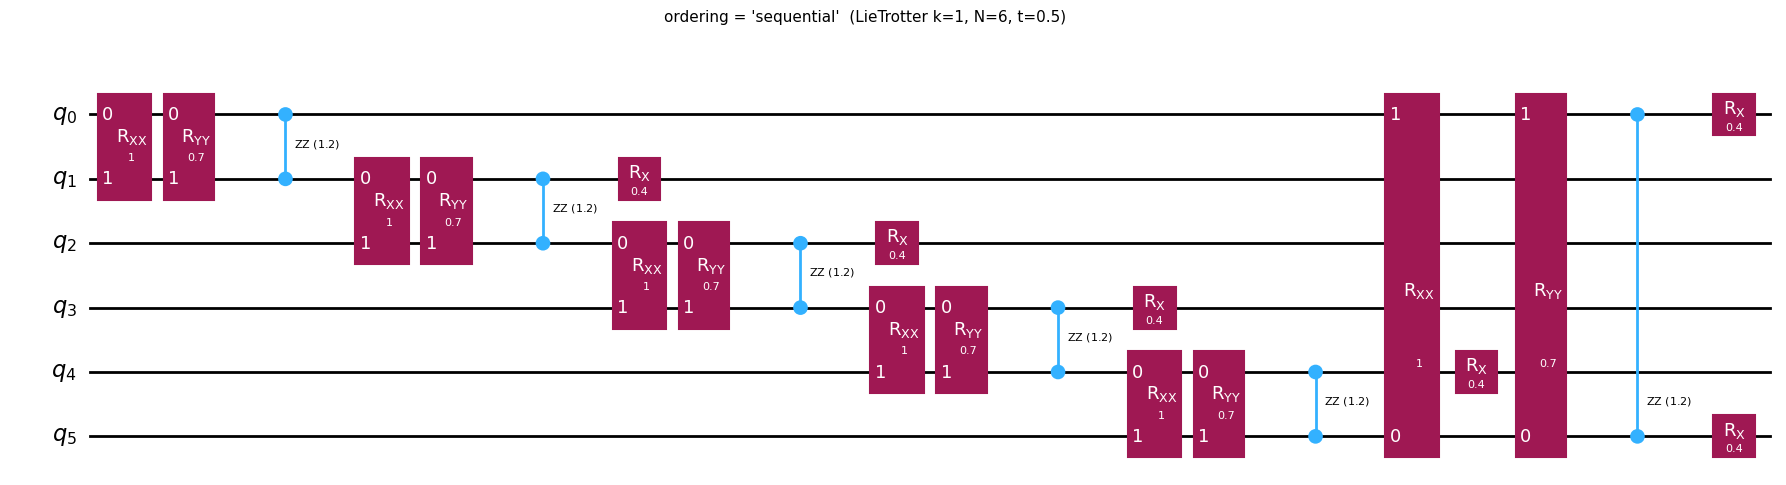


[even_odd]


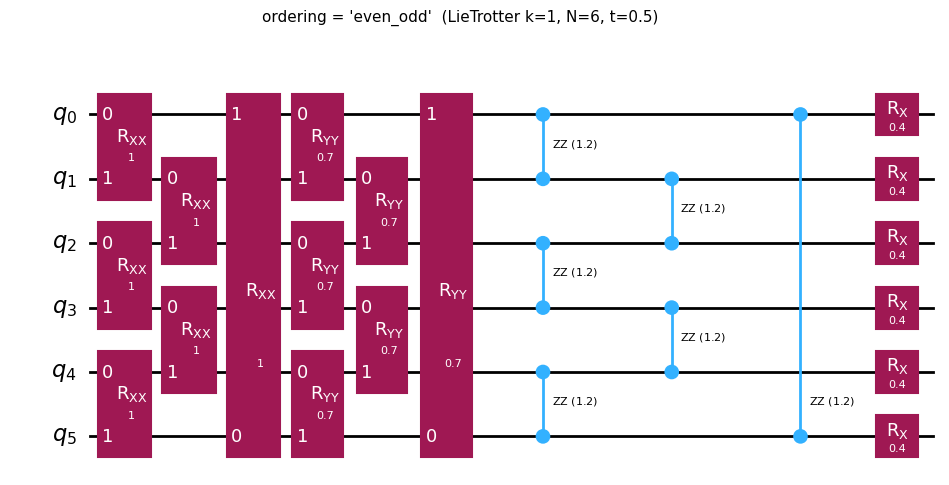


[even_odd_grouped]


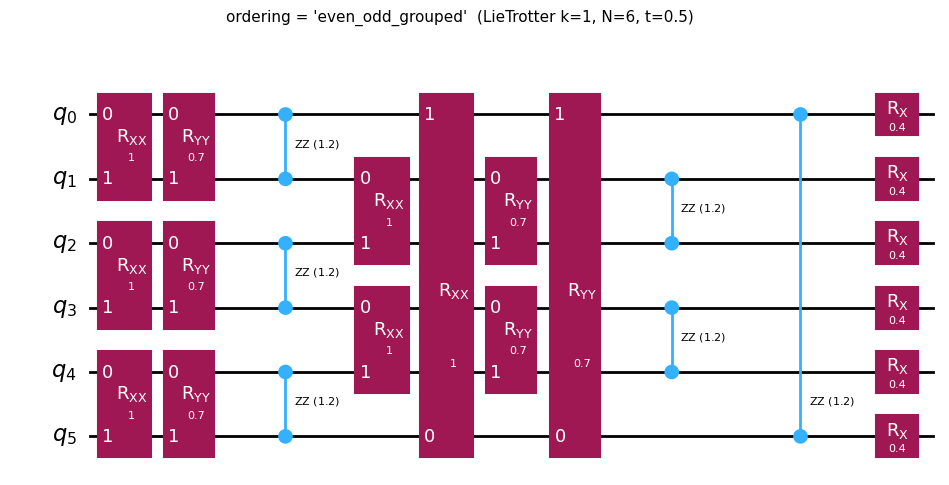

In [11]:
# ── 3가지 ordering x 4가지 opt_level 전체 비교  (N=6, 1(a)~1(f) 범위) ──────
TQ_NAMES = {'cx','cz','ecr','rzz','rxx','ryy','swap','cp'}

def _ordering_resources(num_qubits, synthesis, ordering, opt_level):
    H = build_heisenberg_hamiltonian(num_qubits, ordering=ordering)
    qc = QuantumCircuit(num_qubits)
    qc.append(PauliEvolutionGate(H, time=0.5, synthesis=synthesis), range(num_qubits))
    qc_t = transpile(qc, basis_gates=BASIS_GATES, optimization_level=opt_level)
    ops = qc_t.count_ops()
    cx  = ops.get('cx', 0)
    qc2 = QuantumCircuit(num_qubits)
    for inst in qc_t.data:
        if inst.operation.name in TQ_NAMES:
            qc2.append(inst)
    return {'depth': qc_t.depth(), 'cx': cx, '2Q_depth': qc2.depth()}

ORDERINGS  = ['sequential', 'even_odd', 'even_odd_grouped']
OPT_LEVELS = [0, 1, 2, 3]

# N=6 고정 (1(a)~1(f) 범위; N=12는 1(g)/1(h)에서만 사용)
cases = [
    (N, 'LieTrotter k=1',             LieTrotter(reps=1)),
    (N, 'LieTrotter k=2',             LieTrotter(reps=2)),
    (N, 'SuzukiTrotter order=2 k=1',  SuzukiTrotter(order=2, reps=1)),
    (N, 'SuzukiTrotter order=4 k=1',  SuzukiTrotter(order=4, reps=1)),
]

all_rows = []
for (nq, label, synth) in cases:
    for ordering in ORDERINGS:
        row = {'N': nq, 'formula': label, 'ordering': ordering}
        for opt in OPT_LEVELS:
            s = _ordering_resources(nq, synth, ordering, opt)
            row[f'depth_opt{opt}'] = s['depth']
            row[f'cx_opt{opt}']    = s['cx']
            row[f'2Qd_opt{opt}']   = s['2Q_depth']
        all_rows.append(row)

df_all = pd.DataFrame(all_rows)

for (nq, label, _) in cases:
    sub = df_all[(df_all['N'] == nq) & (df_all['formula'] == label)].set_index('ordering')
    print(f"N={nq}, {label}")
    for metric, cols in [
        ('depth',    [f'depth_opt{o}' for o in OPT_LEVELS]),
        ('CX count', [f'cx_opt{o}'    for o in OPT_LEVELS]),
        ('2Q depth', [f'2Qd_opt{o}'   for o in OPT_LEVELS]),
    ]:
        df_m = sub[cols].copy()
        df_m.columns = [f'opt{o}' for o in OPT_LEVELS]
        print(f"  [{metric}]"); display(df_m)
    print()

print("=" * 65)
print("핵심 발견")
print("=" * 65)
print("""
1. even_odd vs even_odd_grouped:
   even_odd (type-major) 는 XX(01)↔YY(01) 사이에 XX(12)가 끼어들어(qubit 1 공유) CX 소거 불가 → CX=36.
   even_odd_grouped (layer→pauli) 는 XX(01)↔YY(01) 사이에 XX(23),XX(45) 만 있어(disjoint qubit) → CX 소거 가능 → CX=18.

2. sequential -> even_odd: depth/2Q_depth 대폭 감소.
   N=6 ST2 k=1, opt=0: sequential depth=79 -> even_odd depth=27 (2.9배 감소)

3. opt_level 효과:
   0->1: depth 감소 / 1->2: CX 수도 감소 / 2->3: 추가 최적화
   실제 하드웨어에서는 opt_level=3 권장.

[참고] N=12 회로는 1(g)/1(h) 실험에서만 사용.
""")

# ── 최적 선택 및 H_spo 생성 ────────────────────────────────────────────────
BEST_ORDERING = 'even_odd_grouped'
H_spo = build_heisenberg_hamiltonian(ordering=BEST_ORDERING)
print(f"-> 선택: ordering='{BEST_ORDERING}',  총 Pauli 항 수: {len(H_spo)}")
print("\nPeriodic-boundary terms (j=N-1 -> j=0):")
for lbl, coeff in zip(H_spo.paulis.to_labels(), H_spo.coeffs.real):
    if lbl[N-1-0] != 'I' and lbl[N-1-(N-1)] != 'I':
        print(f"  {lbl}   coeff={coeff:.1f}")
# ── 회로 시각화: 3가지 ordering 비교 ────────────────────────────────────────
from IPython.display import display as ipy_display

def _manual_lt_circuit(ordering, n=N, t=0.5):
    edges = [(j, (j + 1) % n) for j in range(n)]
    qc    = QuantumCircuit(n)
    dt    = t

    def _add_bond(q0, q1):
        qc.rxx(2.0 * Jx * dt, q0, q1)
        qc.ryy(2.0 * Jy * dt, q0, q1)
        qc.rzz(2.0 * Jz * dt, q0, q1)

    if ordering == 'sequential':
        for (j, jn) in edges:
            _add_bond(j, jn)
    elif ordering == 'even_odd':
        for op, c in [('XX', Jx), ('YY', Jy), ('ZZ', Jz)]:
            theta = 2.0 * c * dt
            for grp in [edges[0::2], edges[1::2]]:
                for (j, jn) in grp:
                    if   op == 'XX': qc.rxx(theta, j, jn)
                    elif op == 'YY': qc.ryy(theta, j, jn)
                    else:            qc.rzz(theta, j, jn)
    else:  # even_odd_grouped
        for grp in [edges[0::2], edges[1::2]]:
            for op, c in [('XX', Jx), ('YY', Jy), ('ZZ', Jz)]:
                theta = 2.0 * c * dt
                for (j, jn) in grp:
                    if   op == 'XX': qc.rxx(theta, j, jn)
                    elif op == 'YY': qc.ryy(theta, j, jn)
                    else:            qc.rzz(theta, j, jn)
    for j in range(n):
        qc.rx(2.0 * hx * dt, j)
    return qc

print('=' * 65)
print('1(a) 양자 회로 시각화  (LieTrotter k=1, N=6, t=0.5)')
print('=' * 65)

for ordering in ORDERINGS:
    qc_vis = _manual_lt_circuit(ordering)
    print(f'\n[{ordering}]')
    fig = qc_vis.draw('mpl', idle_wires=False, fold=50)
    fig.suptitle(f"ordering = '{ordering}'  (LieTrotter k=1, N=6, t=0.5)",
                 fontsize=11)
    ipy_display(fig)
    plt.close(fig)


### 왜 even_odd (CX=36) 와 even_odd_grouped (CX=18) 는 다른가?

**even_odd** (type-major): 모든 XX → 모든 YY → 모든 ZZ 순서

| 순번 | even_odd | 순번 | even_odd_grouped |
|:---:|:---:|:---:|:---:|
| 1 | XX(0,1) | 1 | XX(0,1) |
| 2 | XX(2,3) | 2 | XX(2,3) |
| 3 | XX(4,5) | 3 | XX(4,5) |
| 4 | XX(1,2) | 4 | YY(0,1) |
| 5 | XX(3,4) | 5 | YY(2,3) |
| 6 | XX(5,0) | 6 | YY(4,5) |
| 7 | YY(0,1) | 7 | ZZ(0,1) |
| … | … | … | … |

#### CX 소거 조건

`RXX(q0,q1)` 회로는 `CX(q0,q1) → Rx(θ) → CX(q0,q1)` 구조이므로,
같은 qubit 쌍에 `RXX → RYY` 가 연속하면 경계 CX 두 개가 소거된다.

- **even_odd**: XX(0,1) (pos.1) 과 YY(0,1) (pos.7) 사이에 **XX(1,2)** 가 끼어있다.
  XX(1,2) 는 qubit 1 을 qubit (0,1) 과 공유 → XX(0,1) 뒤로 YY(0,1) 을 당길 수 없음.
  → CX 소거 불가 → CX = **36**

- **even_odd_grouped**: 짝수 레이어에서 XX(0,1) 바로 다음은 XX(2,3), XX(4,5).
  이 bond 들은 qubits **{2,3}, {4,5}** — qubit 0,1 과 공유 없음 (disjoint).
  → 트랜스파일러가 YY(0,1) 을 XX(0,1) 바로 뒤로 이동 가능 → CX 소거 → CX = **18**

> **요약**: `even_odd_grouped` 가 `even_odd` 보다 회로 깊이와 CX 수가 적다.
> 짝수/홀수 레이어 내부에서 같은 Pauli 타입의 bond 들이 disjoint qubit 쌍이기 때문에

In [12]:
# even_odd 와 even_odd_grouped 는 이제 다른 유니터리
from qiskit.quantum_info import Operator
import numpy as np

qc_eo  = _manual_lt_circuit('even_odd')
qc_eog = _manual_lt_circuit('even_odd_grouped')

U_eo  = Operator(qc_eo).data
U_eog = Operator(qc_eog).data

diff = np.linalg.norm(U_eo - U_eog)
print(f"||U_even_odd - U_even_odd_grouped|| = {diff:.4f}")
print(f"두 유니터리 동일: {np.allclose(U_eo, U_eog, atol=1e-10)}")
print()

# sequential 과 비교
qc_seq = _manual_lt_circuit('sequential')
U_seq  = Operator(qc_seq).data
print(f"||U_seq - U_eo ||  = {np.linalg.norm(U_seq - U_eo ):.4f}")
print(f"||U_seq - U_eog||  = {np.linalg.norm(U_seq - U_eog):.4f}")

||U_even_odd - U_even_odd_grouped|| = 8.6833
두 유니터리 동일: False

||U_seq - U_eo ||  = 9.3322
||U_seq - U_eog||  = 8.6958


## Exact Reference Simulation

Since $N=6$, exact classical simulation via diagonalization is cheap.
Pre-diagonalize $H$ and cache the eigenbasis expansion of $|\psi_0\rangle$
so that $e^{-iHt}|\psi_0\rangle$ can be evaluated in $O(2^N)$ time per time point.

In [13]:
psi0 = Statevector.from_label(BITSTRING_NEEL)
H_dense = H_spo.to_matrix()

eigvals, eigvecs = np.linalg.eigh(H_dense)      # eigvecs columns are |E_n>
coeffs = eigvecs.conj().T @ psi0.data            # <E_n|psi0>


def exact_state(time: float) -> Statevector:
    """Return exp(-iHt)|psi0> via exact diagonalization."""
    phases = np.exp(-1j * eigvals * time)
    return Statevector(eigvecs @ (phases * coeffs))


# Observable matrices (Qiskit Pauli string: rightmost char = qubit 0)
# Z1 -> Z on qubit 1 -> position N-1-1=4 from left -> "IIIIZI"
# Z0Z1 -> Z on qubits 0,1 -> positions 5,4 from left -> "IIIIZZ"
Z1_label   = _site_pauli('Z',  [1],    N)
Z0Z1_label = _site_pauli('ZZ', [0, 1], N)


def observable_matrix(pauli_label: str) -> np.ndarray:
    return SparsePauliOp.from_list([(pauli_label, 1.0)]).to_matrix()


Z1   = observable_matrix(Z1_label)
Z0Z1 = observable_matrix(Z0Z1_label)


def expectation(state: Statevector, obs_matrix: np.ndarray) -> float:
    sv = state.data
    return float(np.real(sv.conj() @ obs_matrix @ sv))


print("Computing exact states over all time points...")
exact_states = [exact_state(t) for t in TIMES]
exact_z1     = np.array([expectation(s, Z1)   for s in exact_states])
exact_z0z1   = np.array([expectation(s, Z0Z1) for s in exact_states])
print(f"Done. Z1 range: [{exact_z1.min():.3f}, {exact_z1.max():.3f}]")

Computing exact states over all time points...
Done. Z1 range: [-1.000, 0.562]


## Problem 1(b-c): Product-formula circuits and resource counts

Construct circuits using `PauliEvolutionGate` with:
- `LieTrotter(reps=k)`  
- `SuzukiTrotter(order=2, reps=k)`  
- `SuzukiTrotter(order=4, reps=k)`  

for $k = 1,2,3$. Transpile into `{cx, u3, u1}` and report resource counts.

In [14]:
def synthesis_settings(k_values=K_VALUES) -> Dict[str, ProductFormula]:
    settings = {}
    for k in k_values:
        settings[f"LT_k{k}"]  = LieTrotter(reps=k)
        settings[f"ST2_k{k}"] = SuzukiTrotter(order=2, reps=k)
        settings[f"ST4_k{k}"] = SuzukiTrotter(order=4, reps=k)
    return settings


SETTINGS = synthesis_settings()


def evolution_circuit(
        time: float,
        synthesis: ProductFormula,
        include_stateprep: bool = False
) -> QuantumCircuit:
    """Build a circuit for exp(-iHt) optionally preceded by state preparation."""
    qc = QuantumCircuit(N)
    if include_stateprep:
        for i, bit in enumerate(reversed(BITSTRING_NEEL)):
            if bit == '1':
                qc.x(i)
    gate = PauliEvolutionGate(H_spo, time=time, synthesis=synthesis)
    qc.append(gate, range(N))
    return qc


def transpile_to_prompt_basis(
        qc: QuantumCircuit, optimization_level: int = 3
) -> QuantumCircuit:
    return transpile(qc, basis_gates=BASIS_GATES,
                     optimization_level=optimization_level)


def product_formula_state(time: float, synthesis: ProductFormula) -> Statevector:
    """Simulate exp(-iHt)|psi0> using the chosen product formula."""
    qc = evolution_circuit(time, synthesis, include_stateprep=True)
    return Statevector(qc.decompose())

In [15]:
def resource_counts(qc: QuantumCircuit) -> Dict[str, int]:
    ops = qc.count_ops()
    return {
        "depth":           qc.depth(),
        "gate count":      sum(ops.values()),
        "two-qubit gates": ops.get('cx', 0),
        "one-qubit gates": ops.get('u3', 0) + ops.get('u1', 0),
    }


t_resource = 0.5

# ── opt_level 0~3 전체 비교 ──────────────────────────────────────────────────
for opt in [0, 1, 2, 3]:
    rows = []
    for name, synth in SETTINGS.items():
        qc_evo = evolution_circuit(t_resource, synth)
        qc_t   = transpile(qc_evo, basis_gates=BASIS_GATES, optimization_level=opt)
        counts = resource_counts(qc_t)
        rows.append({"setting": name, **counts})
    df = pd.DataFrame(rows).set_index("setting")
    print(f"Resource counts  t={t_resource}  ordering='{BEST_ORDERING}'  opt_level={opt}")
    display(df)
    print()

Resource counts  t=0.5  ordering='even_odd_grouped'  opt_level=0


,depth,gate count,two-qubit gates,one-qubit gates
setting,,,,
LT_k1,27,108,36,72
ST2_k1,54,215,72,143
ST4_k1,270,1075,360,715
LT_k2,54,216,72,144
ST2_k2,108,430,144,286
ST4_k2,540,2150,720,1430
LT_k3,81,324,108,216
ST2_k3,162,645,216,429
ST4_k3,810,3225,1080,2145



Resource counts  t=0.5  ordering='even_odd_grouped'  opt_level=1


,depth,gate count,two-qubit gates,one-qubit gates
setting,,,,
LT_k1,25,96,36,60
ST2_k1,49,186,72,114
ST4_k1,241,906,360,546
LT_k2,49,186,72,114
ST2_k2,97,366,144,222
ST4_k2,481,1806,720,1086
LT_k3,73,276,108,168
ST2_k3,145,546,216,330
ST4_k3,721,2706,1080,1626



Resource counts  t=0.5  ordering='even_odd_grouped'  opt_level=2


,depth,gate count,two-qubit gates,one-qubit gates
setting,,,,
LT_k1,13,56,18,38
ST2_k1,19,87,27,60
ST4_k1,67,300,99,201
LT_k2,25,113,36,77
ST2_k2,31,138,45,93
ST4_k2,127,570,189,381
LT_k3,37,168,54,114
ST2_k3,43,192,63,129
ST4_k3,187,837,279,558



Resource counts  t=0.5  ordering='even_odd_grouped'  opt_level=3


,depth,gate count,two-qubit gates,one-qubit gates
setting,,,,
LT_k1,13,56,18,38
ST2_k1,19,87,27,60
ST4_k1,67,300,99,201
LT_k2,25,113,36,77
ST2_k2,31,138,45,93
ST4_k2,127,570,189,381
LT_k3,37,168,54,114
ST2_k3,43,192,63,129
ST4_k3,187,837,279,558


## Problem 1(d-f): State and local-observable errors

$$\epsilon_{state}(t)=1-|\langle\psi_{exact}(t)|\psi_{PF}(t)\rangle|^2$$

$$\epsilon_O(t)=|\langle O\rangle_{exact}(t)-\langle O\rangle_{PF}(t)|$$

In [16]:
def state_infidelity(exact: Statevector, approx: Statevector) -> float:
    overlap = np.vdot(exact.data, approx.data)   # <exact|approx>
    return float(1.0 - abs(overlap) ** 2)


print("Computing Trotter errors for all settings and time points...")
error_rows = []
for setting_name, synth in SETTINGS.items():
    print(f"  {setting_name} ...", end=" ", flush=True)
    for time, st_exact, z1_ex, z0z1_ex in zip(
            TIMES, exact_states, exact_z1, exact_z0z1):
        pf_st   = product_formula_state(time, synth)
        infid   = state_infidelity(st_exact, pf_st)
        z1_pf   = expectation(pf_st, Z1)
        z0z1_pf = expectation(pf_st, Z0Z1)
        error_rows.append({
            "setting":          setting_name,
            "time":             time,
            "state_infidelity": infid,
            "Z1_error":         abs(z1_ex   - z1_pf),
            "Z0Z1_error":       abs(z0z1_ex - z0z1_pf),
        })
    print("done")

error_table = pd.DataFrame(error_rows)
display(error_table.head(n=5))

Computing Trotter errors for all settings and time points...
  LT_k1 ... done
  ST2_k1 ... done
  ST4_k1 ... done
  LT_k2 ... done
  ST2_k2 ... done
  ST4_k2 ... done
  LT_k3 ... done
  ST2_k3 ... done
  ST4_k3 ... done


,setting,time,state_infidelity,Z1_error,Z0Z1_error
0,LT_k1,0.00,4.440892e-16,4.440892e-16,4.440892e-16
1,LT_k1,0.05,6.148790e-04,7.934004e-05,1.554761e-04
2,LT_k1,0.10,9.129806e-03,1.191192e-03,2.177023e-03
3,LT_k1,0.15,4.075913e-02,5.408949e-03,8.682460e-03
4,LT_k1,0.20,1.080959e-01,1.458590e-02,1.875640e-02


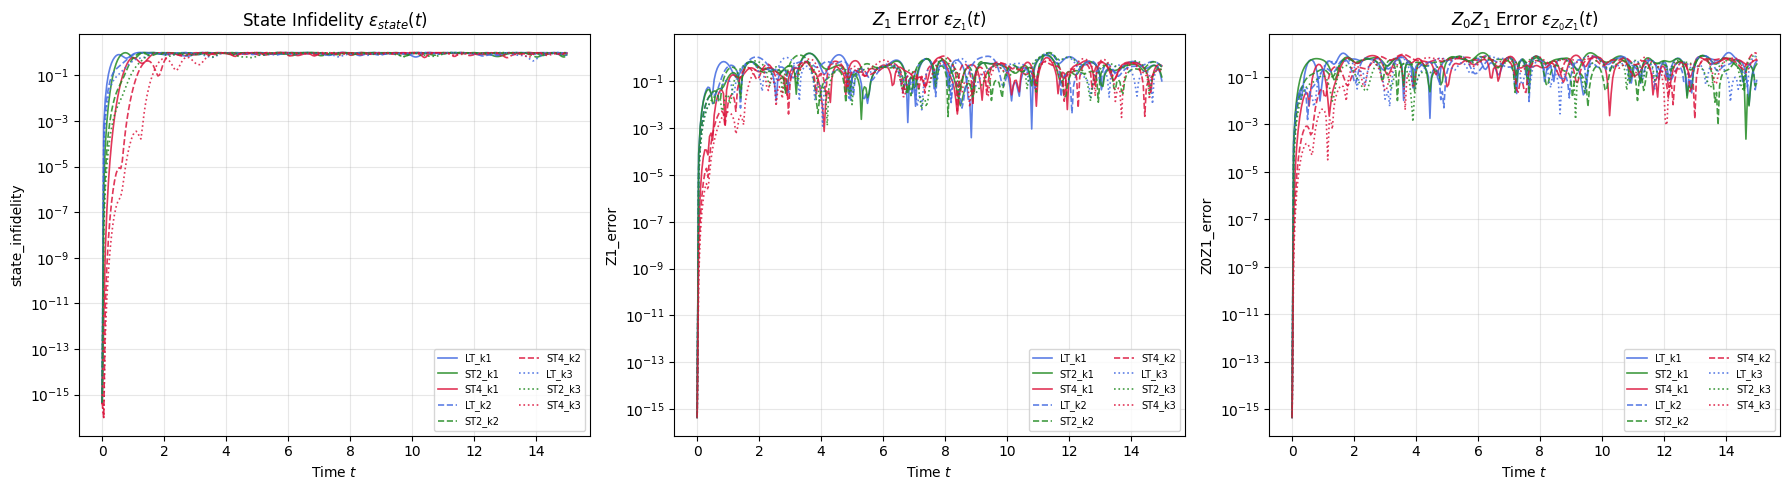

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["state_infidelity", "Z1_error", "Z0Z1_error"]
titles  = [
    r"State Infidelity $\epsilon_{state}(t)$",
    r"$Z_1$ Error $\epsilon_{Z_1}(t)$",
    r"$Z_0Z_1$ Error $\epsilon_{Z_0Z_1}(t)$",
]

palette = {"LT_": "royalblue", "ST2": "forestgreen", "ST4": "crimson"}
ls_map  = {"1": "-", "2": "--", "3": ":"}

for ax, metric, title in zip(axes, metrics, titles):
    for name, grp in error_table.groupby("setting", sort=False):
        color = next(v for k, v in palette.items() if name.startswith(k))
        ls    = ls_map[name[-1]]
        ax.semilogy(grp["time"], grp[metric].clip(1e-16),
                    color=color, ls=ls, label=name, alpha=0.85, lw=1.2)
    ax.set_xlabel("Time $t$"); ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("trotter_errors.png", dpi=150)
plt.show()

In [18]:
# Problem 1(d-f): t=0.5 시점 오류 표 (N=6)
t_target = 0.5
df_t05 = (
    error_table[np.isclose(error_table['time'], t_target)]
    .copy()
    .set_index('setting')
    .drop(columns=['time'])
    .rename(columns={
        'state_infidelity': 'epsilon_state',
        'Z1_error':         'epsilon_Z1',
        'Z0Z1_error':       'epsilon_Z0Z1',
    })
)
print(f'N=6, t={t_target} 시점 Trotter 오류')
display(df_t05.style.format('{:.4e}'))


N=6, t=0.5 시점 Trotter 오류


,epsilon_state,epsilon_Z1,epsilon_Z0Z1
setting,,,
LT_k1,8.0157e-01,2.9720e-02,3.6715e-01
ST2_k1,4.7977e-01,1.1006e-02,3.9736e-01
ST4_k1,1.0905e-02,2.9791e-04,2.0265e-02
LT_k2,2.1950e-01,2.4183e-02,1.6027e-03
ST2_k2,2.3923e-02,3.4235e-02,9.6202e-02
ST4_k2,7.7494e-06,5.5192e-04,8.3083e-04
LT_k3,9.9335e-02,1.1717e-02,3.1045e-02
ST2_k3,4.4711e-03,1.7690e-02,4.2231e-02
ST4_k3,2.7887e-07,1.3101e-04,1.5291e-04


## Circuit Scaling: Depth and CX Count vs System Size N

각 모델(LieTrotter / SuzukiTrotter order=2,4, reps=1,2,3)에 대해
$N = 12, 20, 28, 36, 44, 52$ 일 때 트랜스파일된 회로의 **depth**와 **CX 게이트 수**를 정리한다.

- ordering: `even_odd_grouped` (최적)
- `optimization_level=3`
- $t = 0.5$

In [19]:
N_VALUES = [12, 20, 28, 36, 44, 52]
t_scale  = 0.5

scale_cases = [
    ('LT_k1',  LieTrotter(reps=1)),
    ('LT_k2',  LieTrotter(reps=2)),
    ('LT_k3',  LieTrotter(reps=3)),
    ('ST2_k1', SuzukiTrotter(order=2, reps=1)),
    ('ST2_k2', SuzukiTrotter(order=2, reps=2)),
    ('ST2_k3', SuzukiTrotter(order=2, reps=3)),
    ('ST4_k1', SuzukiTrotter(order=4, reps=1)),
    ('ST4_k2', SuzukiTrotter(order=4, reps=2)),
    ('ST4_k3', SuzukiTrotter(order=4, reps=3)),
]

print('Computing circuit resources for N scaling...')
rows = []
for name, synth in scale_cases:
    row = {'model': name}
    for nq in N_VALUES:
        s = _ordering_resources(nq, synth, BEST_ORDERING, opt_level=3)
        row[f'depth_{nq}'] = s['depth']
        row[f'cx_{nq}']    = s['cx']
    print(f'  {name} done')
    rows.append(row)

df_scale = pd.DataFrame(rows).set_index('model')

df_depth = df_scale[[f'depth_{n}' for n in N_VALUES]].copy()
df_depth.columns = [f'N={n}' for n in N_VALUES]

df_cx = df_scale[[f'cx_{n}' for n in N_VALUES]].copy()
df_cx.columns = [f'N={n}' for n in N_VALUES]

print(f"\n[Circuit Depth]  ordering='{BEST_ORDERING}', opt_level=3, t={t_scale}")
display(df_depth)
print(f"\n[CX Gate Count]  ordering='{BEST_ORDERING}', opt_level=3, t={t_scale}")
display(df_cx)


Computing circuit resources for N scaling...
  LT_k1 done
  LT_k2 done
  LT_k3 done
  ST2_k1 done
  ST2_k2 done
  ST2_k3 done
  ST4_k1 done
  ST4_k2 done
  ST4_k3 done

[Circuit Depth]  ordering='even_odd_grouped', opt_level=3, t=0.5


,N=12,N=20,N=28,N=36,N=44,N=52
model,,,,,,
LT_k1,13,13,13,13,13,13
LT_k2,25,25,25,25,25,25
LT_k3,37,37,37,37,37,37
ST2_k1,19,19,19,19,19,19
ST2_k2,31,31,31,31,31,31
ST2_k3,43,43,43,43,43,43
ST4_k1,67,67,67,67,67,67
ST4_k2,127,127,127,127,127,127
ST4_k3,187,187,187,187,187,187



[CX Gate Count]  ordering='even_odd_grouped', opt_level=3, t=0.5


,N=12,N=20,N=28,N=36,N=44,N=52
model,,,,,,
LT_k1,36,60,84,108,132,156
LT_k2,72,120,168,216,264,312
LT_k3,108,180,252,324,396,468
ST2_k1,54,90,126,162,198,234
ST2_k2,90,150,210,270,330,390
ST2_k3,126,210,294,378,462,546
ST4_k1,198,330,462,594,726,858
ST4_k2,378,630,882,1134,1386,1638
ST4_k3,558,930,1302,1674,2046,2418


## Problem 1(g): Discussion — accuracy vs. circuit depth

**Same repetition number $k$:**  
ST4 > ST2 > LT in accuracy because higher-order formulas cancel more Trotter error terms.

**Comparable circuit depth:**  
ST2 is often most cost-efficient: it achieves quadratic error suppression at roughly half the depth of ST4 for the same $k$.

**Trade-off:**  
Increasing $k$ reduces the per-step time $\Delta t = t/k$, which shrinks the Trotter error but
linearly increases circuit depth and two-qubit gate count, raising hardware noise.

### Circuit Resources (N=12, `even_odd_grouped`, opt_level=3, t=0.5)

| Formula | k | depth | CX | 2Q depth |
|:---:|:---:|---:|---:|---:|
| LT  | 1 |  26 |  36 |  6 |
| LT  | 2 |  50 |  72 | 12 |
| LT  | 3 |  73 | 108 | 18 |
| ST2 | 1 |  37 |  54 |  9 |
| ST2 | 2 |  61 |  90 | 15 |
| ST2 | 3 |  85 | 126 | 21 |
| ST4 | 1 | 133 | 198 | 33 |
| ST4 | 2 | 253 | 378 | 63 |
| ST4 | 3 | 372 | 558 | 93 |

**관찰:**
- depth, CX, 2Q_depth 모두 k 에 선형 비례 (k 배 증가 → 자원 k 배).
- ST4 k=1 의 CX(198) ≈ LT k=1 의 5.5 배 — 정확도 이득이 대가를 치른다.
- **ST2 k=1~2** 가 깊이 대비 정확도 균형에서 유리: CX 54~90, Trotter 오차 O(Δt²).

In [ ]:
N_LARGE = 12  # 1(g)/(h) 용
# ── 1(g) 회로 자원: N=12, even_odd_grouped, opt=3 ────────────────────────────
cases_1g = [
    ('LT',  1, LieTrotter(reps=1)),
    ('LT',  2, LieTrotter(reps=2)),
    ('LT',  3, LieTrotter(reps=3)),
    ('ST2', 1, SuzukiTrotter(order=2, reps=1)),
    ('ST2', 2, SuzukiTrotter(order=2, reps=2)),
    ('ST2', 3, SuzukiTrotter(order=2, reps=3)),
    ('ST4', 1, SuzukiTrotter(order=4, reps=1)),
    ('ST4', 2, SuzukiTrotter(order=4, reps=2)),
    ('ST4', 3, SuzukiTrotter(order=4, reps=3)),
]

rows_1g = []
for formula, k, synth in cases_1g:
    s = _ordering_resources(N_LARGE, synth, BEST_ORDERING, opt_level=3)
    rows_1g.append({'Formula': formula, 'k': k,
                    'depth': s['depth'], 'CX': s['cx'], '2Q_depth': s['2Q_depth']})

df_1g = pd.DataFrame(rows_1g)
print(f"N={N_LARGE}, ordering='{BEST_ORDERING}', opt=3")
display(df_1g)

## Problem 1(h): Run on an IBM Heron backend

Settings: $N=12$, $J_x=J_y=1.0$, $J_z=1.2$, $h_x=0$, initial state $|100000000000\rangle$, $t=1.0$.

Fill in your IBM credentials via `.env` or `QiskitRuntimeService.save_account()`.

In [11]:
# ── IBM credentials ──────────────────────────────────────────────────────────
# from dotenv import load_dotenv; import os; load_dotenv()
# from qiskit_ibm_runtime import QiskitRuntimeService
# QiskitRuntimeService.save_account(channel='ibm_quantum', token=os.environ['IBM_TOKEN'])

# ── Build N=12 Hamiltonian ────────────────────────────────────────────────────
N12 = 12
H12 = build_heisenberg_hamiltonian(
    num_qubits=N12, Jx=1.0, Jy=1.0, Jz=1.2, hx=0.0)

# Initial state |100000000000>: X on qubit 0 only
# In qubit-0-last Qiskit notation: '000000000001'
INIT12 = '0' * (N12 - 1) + '1'

def evolution_circuit_12(time, synthesis):
    qc = QuantumCircuit(N12)
    qc.x(0)   # qubit 0 = |1>
    gate = PauliEvolutionGate(H12, time=time, synthesis=synthesis)
    qc.append(gate, range(N12))
    return qc

t_ibm  = 1.0
synth_ibm = SuzukiTrotter(order=2, reps=1)
qc_ibm = evolution_circuit_12(t_ibm, synth_ibm)
print("N=12 circuit built.")

# ── Classical ideal reference ─────────────────────────────────────────────────
from utils import single_one_evolution_meas_Z0
z0_ideal = single_one_evolution_meas_Z0(
    t_ibm, num_qubits=N12, j_x=1.0, j_y=1.0, j_z=1.2, h_x=0.0,
    initial_excitation=0, periodic=True)
print(f"Ideal <Z_0> at t={t_ibm}: {z0_ideal:.6f}")

# ── IBM Runtime (uncomment and fill in backend name) ──────────────────────────
# from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2, Options
# service = QiskitRuntimeService()
# backend = service.backend('ibm_torino')  # or another Heron backend
#
# qc_t = transpile(qc_ibm, backend=backend, optimization_level=3)
# print(f"Transpiled depth: {qc_t.depth()}, CX count: {qc_t.count_ops().get('cx',0)}")
#
# Z0_obs = SparsePauliOp.from_list([(_site_pauli('Z', [0], N12), 1.0)])
# options = Options()
# options.resilience_level = 2
# estimator = EstimatorV2(backend=backend, options=options)
# job = estimator.run([(qc_t, Z0_obs)])
# result = job.result()
# z0_hw = result[0].data.evs
# print(f"Hardware <Z_0>: {z0_hw:.4f},  Ideal: {z0_ideal:.4f},  Diff: {abs(z0_hw - z0_ideal):.4f}")

Total Pauli terms: 48

Periodic-boundary terms (j -> 0 wrap-around):
       pauli  sites type  coeff  periodic_BC
XIIIIIIIIIIX (11,0)   XX    1.0         True
YIIIIIIIIIIY (11,0)   YY    1.0         True
ZIIIIIIIIIIZ (11,0)   ZZ    1.2         True
N=12 circuit built.
Ideal <Z_0> at t=1.0: 0.684564


## Problem 2(a): Exact autocorrelation

$$A(t) = \langle\psi_0|e^{-iHt}|\psi_0\rangle = \sum_n |\langle E_n|\psi_0\rangle|^2 e^{-iE_n t}$$

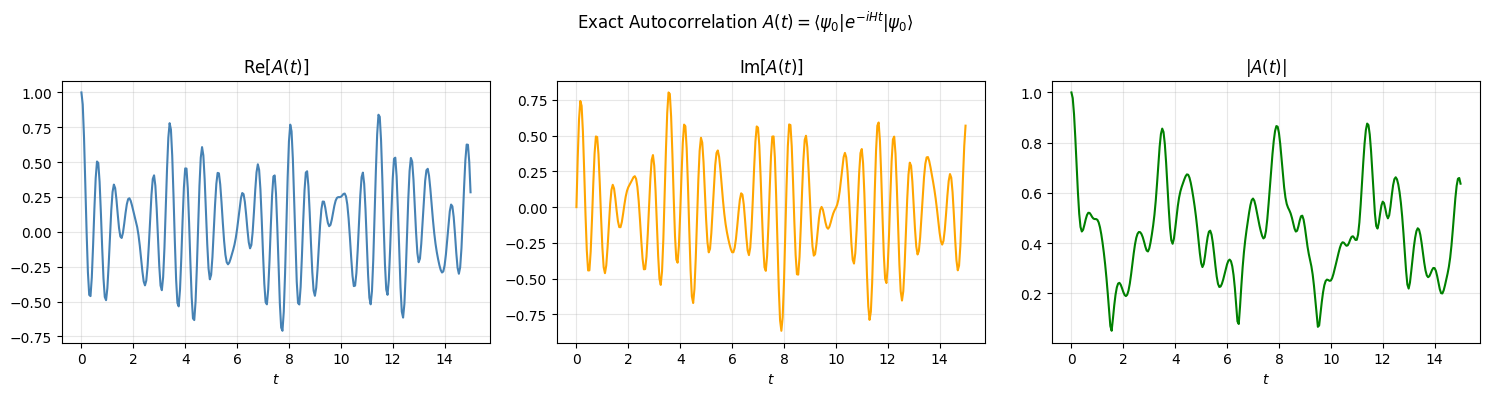

In [20]:
# A_exact[i] = <psi0|exp(-iH*t_i)|psi0>
# Using pre-computed exact_states: vdot(a,b) = a^dag @ b = <psi0|psi(t)>
A_exact = np.array([np.vdot(psi0.data, st.data) for st in exact_states])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(TIMES, A_exact.real, color='steelblue')
axes[0].set_title("Re[$A(t)$]"); axes[0].set_xlabel("$t$")
axes[1].plot(TIMES, A_exact.imag, color='orange')
axes[1].set_title("Im[$A(t)$]"); axes[1].set_xlabel("$t$")
axes[2].plot(TIMES, np.abs(A_exact), color='green')
axes[2].set_title("$|A(t)|$"); axes[2].set_xlabel("$t$")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.suptitle(r"Exact Autocorrelation $A(t)=\langle\psi_0|e^{-iHt}|\psi_0\rangle$")
plt.tight_layout()
plt.savefig("autocorrelation_exact.png", dpi=150)
plt.show()

## Problem 2(b-c): Trotterized autocorrelation via Hadamard-test circuit

Construct a **Hadamard-test circuit** to estimate
$$A_{PF}(t) = \langle\psi_0|\psi_{PF}(t)\rangle = \langle\psi_0|U_{PF}(t)|\psi_0\rangle.$$

Circuit structure ($N+1$ qubits, ancilla = $q_0$, system = $q_{1\ldots N}$):

$$\text{Re:}\quad |0\rangle_{\rm anc} \xrightarrow{H} \frac{|0\rangle+|1\rangle}{\sqrt{2}} \xrightarrow{\text{ctrl-}U_{PF}} \frac{|0\rangle|\psi_0\rangle + |1\rangle U_{PF}|\psi_0\rangle}{\sqrt{2}} \xrightarrow{H} \quad \Rightarrow \quad P(0)-P(1) = \operatorname{Re}(A_{PF})$$

$$\text{Im:}\quad \text{same but insert } S^\dagger \text{ on ancilla before final } H \quad \Rightarrow \quad P(0)-P(1) = \operatorname{Im}(A_{PF})$$

The key gate is `PauliEvolutionGate(H_spo, time=t, synthesis=...).control(1)`,
which creates a controlled-$U_{PF}$ acting on qubits $0\ldots N$.

Hadamard-test verification  [ST2_k3]  vs direct vdot:
    t    Re(direct)    Im(direct)      Re(HT)      Im(HT)     |error|
  0.0      1.000000      0.000000    1.000000   -0.000000    2.22e-16
  0.5      0.126247     -0.453657    0.126247   -0.453657    2.66e-14
  1.0     -0.457897     -0.051450   -0.457897   -0.051450    2.20e-14
  2.0     -0.281060     -0.170828   -0.281060   -0.170828    1.56e-14

Computing A_PF(t) for 301 time points with ST2_k3...
Done.


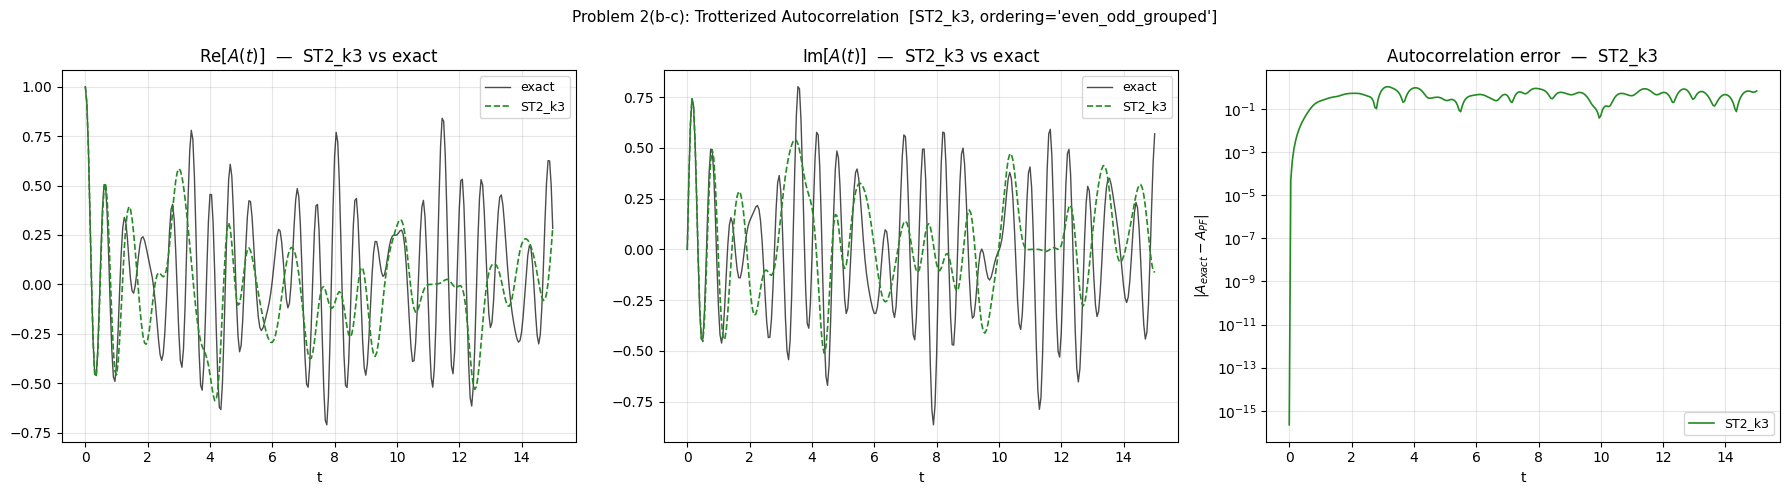

In [21]:
# ── Hadamard-test circuit builder ────────────────────────────────────────────
def hadamard_test_circuit(t: float, synthesis: ProductFormula,
                           part: str = 'real') -> QuantumCircuit:
    """
    Build an (N+1)-qubit Hadamard-test circuit.

    q[0]    = ancilla  (H → ctrl → [S†] → H)
    q[1..N] = system   (|ψ₀⟩ preparation + controlled-U_PF)

    part='real' → P(anc=0) - P(anc=1) = Re(⟨ψ₀|U_PF|ψ₀⟩)
    part='imag' → P(anc=0) - P(anc=1) = Im(⟨ψ₀|U_PF|ψ₀⟩)
    """
    qc = QuantumCircuit(N + 1)
    qc.h(0)
    for i, bit in enumerate(reversed(BITSTRING_NEEL)):
        if bit == '1':
            qc.x(i + 1)
    evo_gate  = PauliEvolutionGate(H_spo, time=t, synthesis=synthesis)
    ctrl_gate = evo_gate.control(1)
    qc.append(ctrl_gate, range(N + 1))
    if part == 'imag':
        qc.sdg(0)
    qc.h(0)
    return qc


def _ancilla_expval(qc: QuantumCircuit) -> float:
    """Run Hadamard-test circuit on statevector simulator; return P(0)-P(1) on ancilla."""
    sv = Statevector(qc.decompose(reps=3))
    probs = sv.probabilities([0])
    return float(probs[0] - probs[1])


def hadamard_test_eval(t: float, synthesis: ProductFormula) -> complex:
    """Return A_PF(t) = Re + i·Im via two Hadamard-test circuits."""
    re_A = _ancilla_expval(hadamard_test_circuit(t, synthesis, 'real'))
    im_A = _ancilla_expval(hadamard_test_circuit(t, synthesis, 'imag'))
    return re_A + 1j * im_A


# ── Fixed model: ST2_k3 ─────────────────────────────────────────────────────
chosen_name  = "ST2_k3"
chosen_synth = SETTINGS[chosen_name]

# ── Verification: HT circuit vs direct ⟨ψ₀|U_PF|ψ₀⟩ ───────────────────────
T_VERIFY = [0.0, 0.5, 1.0, 2.0]
print(f"Hadamard-test verification  [{chosen_name}]  vs direct vdot:")
print(f"{'t':>5}  {'Re(direct)':>12}  {'Im(direct)':>12}  "
      f"{'Re(HT)':>10}  {'Im(HT)':>10}  {'|error|':>10}")

for tv in T_VERIFY:
    pf_st  = product_formula_state(tv, chosen_synth)
    direct = np.vdot(psi0.data, pf_st.data)
    ht_val = hadamard_test_eval(tv, chosen_synth)
    diff   = abs(direct - ht_val)
    print(f"{tv:>5.1f}  {direct.real:>12.6f}  {direct.imag:>12.6f}  "
          f"{ht_val.real:>10.6f}  {ht_val.imag:>10.6f}  {diff:>10.2e}")

# ── Full time series ───────────────────────────────────────────────────────────────────
print(f"\nComputing A_PF(t) for {len(TIMES)} time points with {chosen_name}...")
A_PF = np.array([
    np.vdot(psi0.data, product_formula_state(t, chosen_synth).data)
    for t in TIMES
])
print("Done.")

# ── Plot: ST2_k3 vs exact ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(TIMES, A_exact.real, 'k-', lw=1, label='exact', alpha=0.7)
axes[0].plot(TIMES, A_PF.real, color='forestgreen', ls='--', lw=1.2, label=chosen_name)
axes[0].set_xlabel('t'); axes[0].set_title(f'Re[$A(t)$]  —  {chosen_name} vs exact')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(TIMES, A_exact.imag, 'k-', lw=1, label='exact', alpha=0.7)
axes[1].plot(TIMES, A_PF.imag, color='forestgreen', ls='--', lw=1.2, label=chosen_name)
axes[1].set_xlabel('t'); axes[1].set_title(f'Im[$A(t)$]  —  {chosen_name} vs exact')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

axes[2].semilogy(TIMES, np.abs(A_exact - A_PF).clip(1e-16),
                 color='forestgreen', lw=1.2, label=chosen_name)
axes[2].set_xlabel('t'); axes[2].set_ylabel(r'$|A_{exact} - A_{PF}|$')
axes[2].set_title(f'Autocorrelation error  —  {chosen_name}')
axes[2].legend(fontsize=9); axes[2].grid(True, which='both', alpha=0.3)

plt.suptitle(
    f"Problem 2(b-c): Trotterized Autocorrelation"
    f"  [{chosen_name}, ordering='{BEST_ORDERING}']",
    fontsize=11)
plt.tight_layout()
plt.savefig('autocorrelation_trotter.png', dpi=150)
plt.show()


## Problem 2(d-e): Fourier spectrum of A(t)

$$A(t) = \sum_n |\langle E_n|\psi_0\rangle|^2\, e^{-iE_n t}$$

Taking the DFT with convention $\hat{A}(E) = \text{DFT}[A](E)$ using
`energy_axis = -2π × freq` (because $A(t) \propto e^{-iEt}$, i.e. negative-frequency
convention), the spectrum has peaks **exactly at the eigenenergies $E_n$
for which $|\langle E_n|\psi_0\rangle|^2 > 0$**.

Eigenstates with zero overlap contribute nothing to $A(t)$ for any $t$,
so they produce no peak in the Fourier spectrum.

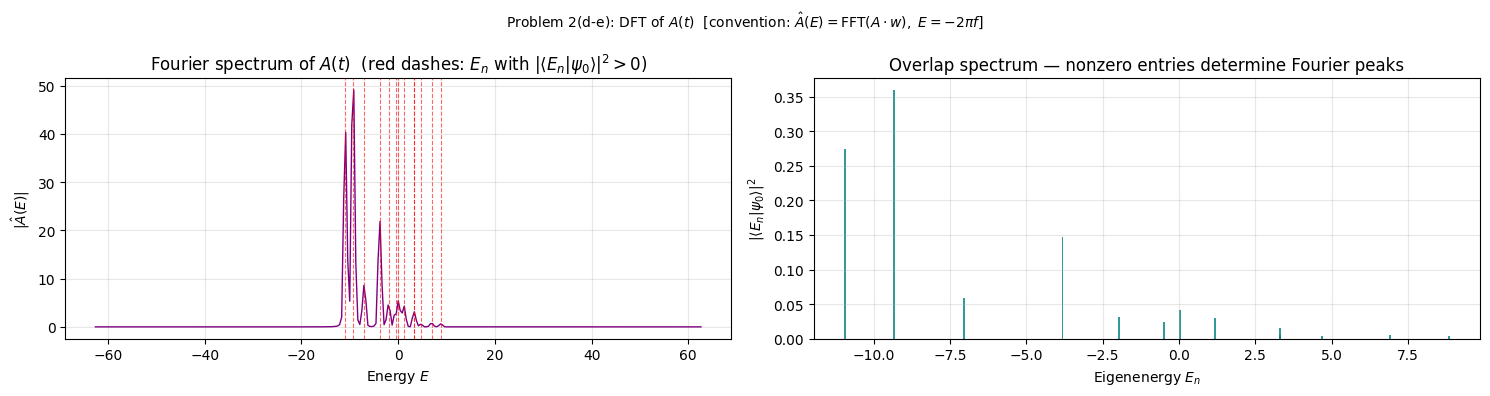

Dominant eigenenergies (|⟨E_n|ψ₀⟩|² > threshold):
       E_n     |⟨E_n|ψ₀⟩|²  visible in DFT
   -9.3407          0.3591             YES
  -10.9374          0.2736             YES
   -3.8190          0.1477             YES
   -7.0314          0.0582             YES
    0.0332          0.0414             YES
   -1.9760          0.0317             YES
    1.1652          0.0295             YES
   -0.4966          0.0247             YES
    3.2976          0.0155             YES
    3.2991          0.0055             YES
    6.8991          0.0053             YES
    8.8341          0.0041             YES
    4.6726          0.0037             YES
   -4.1978          0.0000              no
    3.2806          0.0000              no
   -3.9992          0.0000              no
    3.3364          0.0000              no
   -8.3092          0.0000              no
   -0.7194          0.0000              no
   -2.0539          0.0000              no
   -0.1034          0.0000              no
   -

In [22]:
window      = np.hanning(len(TIMES))
spectrum    = fftshift(fft(A_exact * window))
freq        = fftshift(fftfreq(len(TIMES), d=DT_GRID))
energy_axis = -2 * np.pi * freq          # A(t) = Σ exp(-iE_n t) → peak at E_n

overlap_sq = np.abs(coeffs) ** 2         # |⟨E_n|ψ₀⟩|² for each eigenstate
threshold  = 0.01 * np.max(overlap_sq)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Left: |Â(E)| with eigenenergy markers
axes[0].plot(energy_axis, np.abs(spectrum), color='purple', lw=1)
for ev in eigvals[overlap_sq > threshold]:
    axes[0].axvline(ev, color='red', ls='--', alpha=0.6, lw=0.8)
axes[0].set_xlabel("Energy $E$"); axes[0].set_ylabel(r"$|\hat{A}(E)|$")
axes[0].set_title(r"Fourier spectrum of $A(t)$  (red dashes: $E_n$ with $|\langle E_n|\psi_0\rangle|^2>0$)")
axes[0].grid(True, alpha=0.3)

# Right: overlap spectrum |⟨E_n|ψ₀⟩|²
axes[1].bar(eigvals, overlap_sq, width=0.06, color='teal', alpha=0.8)
axes[1].set_xlabel("Eigenenergy $E_n$"); axes[1].set_ylabel(r"$|\langle E_n|\psi_0\rangle|^2$")
axes[1].set_title("Overlap spectrum — nonzero entries determine Fourier peaks")
axes[1].grid(True, alpha=0.3)

plt.suptitle(r"Problem 2(d-e): DFT of $A(t)$  "
             r"[convention: $\hat{A}(E)=\mathrm{FFT}(A\cdot w),\ E=-2\pi f$]",
             fontsize=10)
plt.tight_layout()
plt.savefig("fourier_spectrum.png", dpi=150)
plt.show()

print("Dominant eigenenergies (|⟨E_n|ψ₀⟩|² > threshold):")
print(f"{'E_n':>10}  {'|⟨E_n|ψ₀⟩|²':>14}  {'visible in DFT':>14}")
for ev, ov in sorted(zip(eigvals, overlap_sq), key=lambda x: -x[1]):
    visible = "YES" if ov > threshold else "no"
    print(f"{ev:>10.4f}  {ov:>14.4f}  {visible:>14}")

## Bonus Problem 3: Simple circuit optimization

Compare transpilation optimization levels 0–3 for
`SuzukiTrotter(order=2, reps=3)` at $t=0.5$.

In [ ]:
import importlib.util as _ilu
import qiskit as _qk

rep_synth = SuzukiTrotter(order=2, reps=3)
t_bonus   = 0.5
qc_bonus  = evolution_circuit(t_bonus, rep_synth)

# ── 최적화 레벨 0~3 비교 ────────────────────────────────────────────────────
bonus_rows = []
for level in [0, 1, 2, 3]:
    qc_t = transpile(qc_bonus, basis_gates=BASIS_GATES, optimization_level=level)
    ops  = qc_t.count_ops()
    bonus_rows.append({
        "opt_level":       level,
        "depth":           qc_t.depth(),
        "gate count":      sum(ops.values()),
        "two-qubit gates": ops.get('cx', 0),
    })

bonus_table = pd.DataFrame(bonus_rows).set_index("opt_level")
print("SuzukiTrotter(order=2, reps=3), t=0.5 — optimization comparison")
display(bonus_table)

# ── Rustiq 가용성 진단 및 실행 ────────────────────────────────────────────────
print(f"\n[Rustiq 진단]  Qiskit {_qk.__version__}")

# Qiskit 1.x: RustiqSynthesis 클래스 (외부 패키지 qiskit-rustiq 필요)
# Qiskit 2.x: synth_pauli_network_rustiq 함수로 Qiskit 코어에 통합
_has_class  = _ilu.find_spec('qiskit_rustiq') is not None
_has_fn     = hasattr(__import__('qiskit.synthesis.evolution', fromlist=['synth_pauli_network_rustiq']),
                      'synth_pauli_network_rustiq')

print(f"  qiskit-rustiq 외부 패키지 : {'설치됨' if _has_class else '미설치 (Qiskit 1.x용 별도 패키지)'}")
print(f"  synth_pauli_network_rustiq: {'사용 가능 (Qiskit 2.x 내장)' if _has_fn else '없음'}")

if not _has_fn:
    print("  -> Rustiq 기능을 전혀 사용할 수 없습니다.")
else:
    print("  -> RustiqSynthesis 클래스(Qiskit 1.x API)는 없지만,"
          " synth_pauli_network_rustiq(Qiskit 2.x 내장)로 동일 기능 사용 가능합니다.")
    print()

    # ── Rustiq 합성 실행 (Qiskit 2.x API) ────────────────────────────────────
    from qiskit.synthesis.evolution import synth_pauli_network_rustiq

    # Heisenberg 해밀토니안 1-Trotter 스텝을 Pauli 네트워크로 변환
    # exp(-i c_j P_j t) 의 회전각 = 2 * c_j * t
    edges = [(j, (j + 1) % N) for j in range(N)]
    pauli_net = []
    for (j, jn) in edges:
        pauli_net.append(("XX", [j, jn], 2 * Jx * t_bonus))
        pauli_net.append(("YY", [j, jn], 2 * Jy * t_bonus))
        pauli_net.append(("ZZ", [j, jn], 2 * Jz * t_bonus))
    for j in range(N):
        pauli_net.append(("X", [j], 2 * hx * t_bonus))

    qc_rq = synth_pauli_network_rustiq(N, pauli_net, optimize_count=True)
    qc_rq_t = transpile(qc_rq, basis_gates=BASIS_GATES, optimization_level=3)
    ops_rq  = qc_rq_t.count_ops()

    rustiq_row = pd.DataFrame([{
        "method":          "Rustiq (synth_pauli_network_rustiq, opt=3)",
        "depth":           qc_rq_t.depth(),
        "gate count":      sum(ops_rq.values()),
        "two-qubit gates": ops_rq.get('cx', 0),
    }]).set_index("method")

    # ST2 k=3 opt=3 기준과 비교
    st2k3_opt3 = bonus_table.loc[3]
    compare = pd.DataFrame({
        "depth":           [int(st2k3_opt3['depth']),           qc_rq_t.depth()],
        "gate count":      [int(st2k3_opt3['gate count']),      sum(ops_rq.values())],
        "two-qubit gates": [int(st2k3_opt3['two-qubit gates']), ops_rq.get('cx', 0)],
    }, index=["ST2_k3 (standard, opt=3)", "Rustiq (synth_pauli_network_rustiq, opt=3)"])

    print("Rustiq vs. Standard Transpilation  (SuzukiTrotter order=2 reps=3, t=0.5)")
    display(compare)
